# Anime Recommender System

**Author**: Ntsikelelo Myesi  
**Project**: ExploreAI – Unsupervised Learning  
**Submission Date**: 15 April 2025  
**Kaggle Score**: 1.14313 (Ranked #6 on leaderboard)

---

This project builds a collaborative filtering-based recommender system to predict how users might rate unseen anime titles. The final model was deployed in a Streamlit app and validated on Kaggle.

# Import Libraries
- Imported core libraries: pandas, numpy, matplotlib, seaborn
- Imported tools for recommendation: TfidfVectorizer, cosine_similarity, SVD from surprise

In [1]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt

import seaborn as sns

# Text processing (for content-based filtering)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Collaborative filtering
from surprise import Dataset, Reader, SVD
from surprise.model_selection import cross_validate, train_test_split

# Warnings
import warnings
warnings.filterwarnings('ignore')

# Load Data
- Loaded anime.csv, train.csv, test.csv, and submission.csv using pd.read_csv()


In [3]:
# Load anime metadata
anime_df = pd.read_csv("anime.csv")

# Load user ratings
train_df = pd.read_csv("train.csv")

# Load test set
test_df = pd.read_csv("test.csv")

# (Optional) Load submission format
submission_df = pd.read_csv("submission.csv")

# EDA Process
### Initial EDA on anime.csv
- Checked dataset shape and info
- Identified missing values in genre, type, and rating
- Explored descriptive stats of numerical columns
- Explored sample genres and types


In [9]:
print(f"Shape: {anime_df.shape}")
anime_df.head()
anime_df.info()

Shape: (12294, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12294 entries, 0 to 12293
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   anime_id  12294 non-null  int64  
 1   name      12294 non-null  object 
 2   genre     12232 non-null  object 
 3   type      12269 non-null  object 
 4   episodes  12294 non-null  object 
 5   rating    12064 non-null  float64
 6   members   12294 non-null  int64  
dtypes: float64(1), int64(2), object(4)
memory usage: 672.5+ KB


### Check Missing Values
- Investigated correlation between missing genre and members
- Found that rows with missing genre had low member counts → less impactful
- Identified that rows with missing type had no rating → incomplete entries


In [12]:
anime_df[anime_df['rating'].isnull()]

,anime_id,name,genre,type,episodes,rating,members
8968,34502,Inazma Delivery,"Action, Comedy, Sci-Fi",TV,10,NaN,32
9657,34309,Nananin no Ayakashi: Chimi Chimi Mouryou!! Gen...,"Comedy, Supernatural",TV,Unknown,NaN,129
10896,34096,Gintama (2017),"Action, Comedy, Historical, Parody, Samurai, S...",TV,Unknown,NaN,13383
10897,34134,One Punch Man 2,"Action, Comedy, Parody, Sci-Fi, Seinen, Super ...",TV,Unknown,NaN,90706
10898,30484,Steins;Gate 0,"Sci-Fi, Thriller",NaN,Unknown,NaN,60999
...,...,...,...,...,...,...,...
12274,34492,Nuki Doki! Tenshi to Akuma no Sakusei Battle -...,Hentai,OVA,Unknown,NaN,392
12279,34491,Sagurare Otome The Animation,Hentai,OVA,1,NaN,79
12280,34312,Saimin Class,Hentai,OVA,Unknown,NaN,240
12282,34388,Shikkoku no Shaga The Animation,Hentai,OVA,Unknown,NaN,195


In [14]:
anime_df.isnull().sum()

anime_id      0
name          0
genre        62
type         25
episodes      0
rating      230
members       0
dtype: int64

In [16]:
anime_df.describe()

,anime_id,rating,members
count,12294.000000,12064.000000,1.229400e+04
mean,14058.221653,6.473902,1.807134e+04
std,11455.294701,1.026746,5.482068e+04
min,1.000000,1.670000,5.000000e+00
25%,3484.250000,5.880000,2.250000e+02
50%,10260.500000,6.570000,1.550000e+03
75%,24794.500000,7.180000,9.437000e+03
max,34527.000000,10.000000,1.013917e+06


## Data Cleaning for anime.csv
- Dropped rows with missing rating (no target to learn from)
- Verified remaining missing values
- Decided to impute genre with 'Unknown' (only 47 left)
- Converted episodes to numeric; handled 'Unknown' values
- Ensured all remaining columns are clean and ready for modeling

In [18]:
anime_df['type'].value_counts()

# Some samples of genres
anime_df['genre'].dropna().sample(5).values

array(['Action, Adventure', 'Adventure, Fantasy, Kids', 'Hentai', 'Music',
       'Action, Sci-Fi'], dtype=object)

In [20]:
# How many missing genre values by type
anime_df[anime_df['genre'].isnull()]['type'].value_counts()

# Average members for rows with missing genre
anime_df.groupby(anime_df['genre'].isnull())['members'].mean()

genre
False    18159.224330
True       732.387097
Name: members, dtype: float64

In [22]:
# How many missing type values by genre (fill genre first to avoid error)
anime_df_temp = anime_df.copy()
anime_df_temp['genre'].fillna('Unknown', inplace=True)
anime_df_temp[anime_df_temp['type'].isnull()]['genre'].value_counts()

# Compare average ratings for rows with and without missing type
anime_df.groupby(anime_df['type'].isnull())['rating'].mean()

type
False    6.473902
True          NaN
Name: rating, dtype: float64

In [24]:
# Step 1: Drop rows without ratings
anime_df = anime_df[~anime_df['rating'].isnull()]

# Step 2: Re-check for missing values in remaining data
anime_df.isnull().sum()

anime_id     0
name         0
genre       47
type         0
episodes     0
rating       0
members      0
dtype: int64

In [26]:
# Impute 'Unknown' for now to preserve data
anime_df['genre'].fillna('Unknown', inplace=True)
anime_df.isnull().sum()

anime_id    0
name        0
genre       0
type        0
episodes    0
rating      0
members     0
dtype: int64

## Exploratory Data Analysis – User Ratings

The `train.csv` file contains over 5.7 million user-anime ratings across nearly 70,000 users.

### Key Observations Below:
- Ratings are on a scale from 1 to 10.
- The majority of ratings are between 7 and 10.
- Very few ratings are below 5.
- There are no missing or invalid ratings in the dataset.

This positive skew is common in recommendation systems, where users tend to rate content they enjoy more frequently.

In [28]:
print(f"Shape: {train_df.shape}")
train_df.head()
train_df.info()

Shape: (5703555, 3)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5703555 entries, 0 to 5703554
Data columns (total 3 columns):
 #   Column    Dtype
---  ------    -----
 0   user_id   int64
 1   anime_id  int64
 2   rating    int64
dtypes: int64(3)
memory usage: 130.5 MB


In [30]:
train_df.isnull().sum()
train_df['rating'].value_counts().sort_index()

rating
1       14937
2       20864
3       37354
4       93768
5      254419
6      573994
7     1237905
8     1481186
9     1128665
10     860463
Name: count, dtype: int64

In [32]:
train_df.describe()

# How many unique users and anime
print(f"Unique users: {train_df['user_id'].nunique()}")
print(f"Unique anime: {train_df['anime_id'].nunique()}")

Unique users: 69481
Unique anime: 9838


In [34]:
# Check if any -1 ratings exist
(train_df['rating'] == -1).sum()


0

### Distribution of Ratings

Most ratings fall between 7 and 10, with 8 being the most common. This indicates a strong bias toward positive feedback.

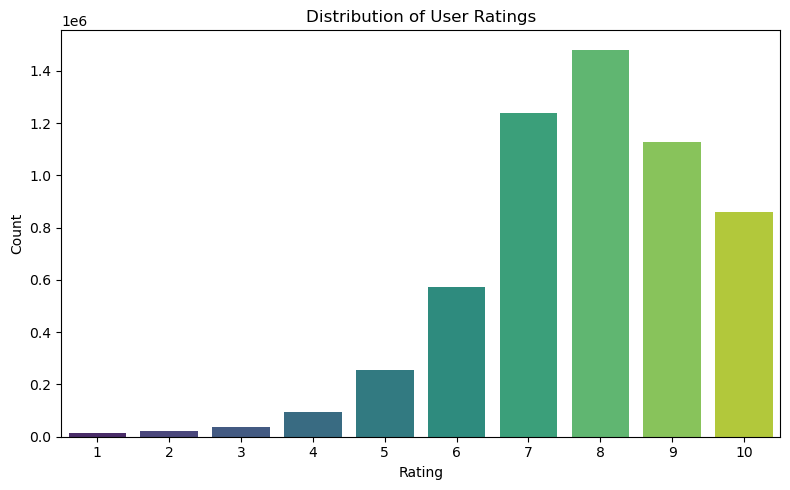

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.countplot(x='rating', data=train_df, palette='viridis')
plt.title('Distribution of User Ratings')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Top 10 Most Rated Anime

The most rated anime titles include well-known series like Death Note, Sword Art Online, and Attack on Titan. These titles have large fan bases and high interaction volumes, making them valuable for training.

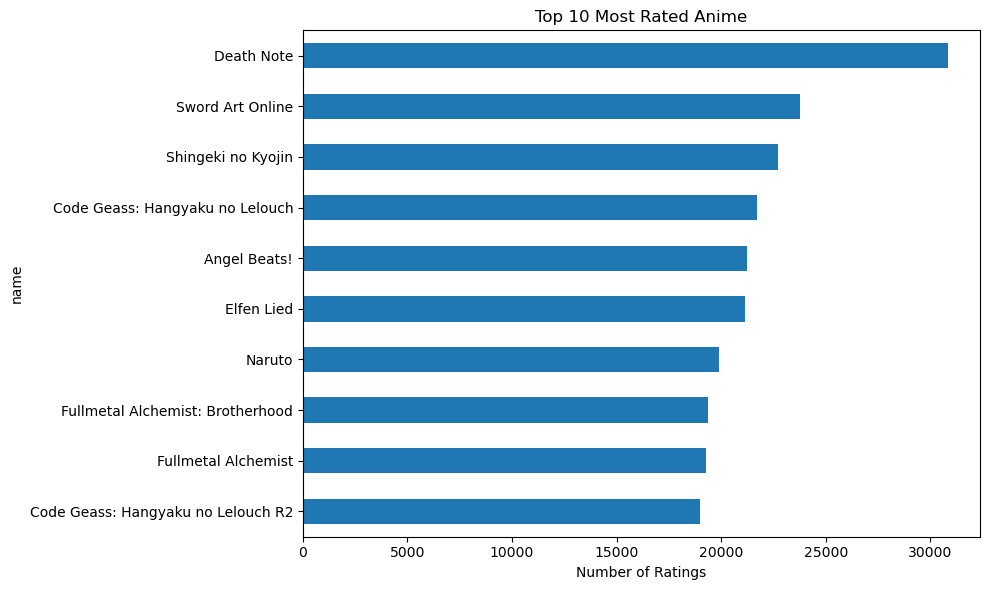

In [8]:
# Merge ratings with anime metadata
merged_df = train_df.merge(anime_df[['anime_id', 'name']], on='anime_id')

# Count ratings per anime
top_rated = merged_df['name'].value_counts().head(10)

# Plot
plt.figure(figsize=(10, 6))
top_rated.plot(kind='barh')
plt.title('Top 10 Most Rated Anime')
plt.xlabel('Number of Ratings')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Modeling with SVD
## Why SVD Was Chosen

The SVD (Singular Value Decomposition) algorithm was selected as the core model for this project due to its strengths in collaborative filtering tasks.

### Key Reasons:
- Well-suited for **sparse rating matrices**, where most users rate only a few items
- Captures **latent relationships** between users and anime through matrix factorization
- Handles large-scale datasets efficiently
- Built-in support in the `surprise` library, making it easy to implement and evaluate
- Performs well even **without additional user or item metadata**
- Can be tuned easily using **GridSearchCV** to improve accuracy

## Collaborative Filtering with SVD

To build a recommendation model, we applied **Singular Value Decomposition (SVD)** using the `surprise` library.

### Steps:
1. Loaded user-anime-rating data into `surprise` format
2. Trained a base SVD model
3. Performed GridSearchCV to tune:
   - `n_factors`: 100
   - `lr_all`: 0.01
   - `reg_all`: 0.1
4. Evaluated the model using RMSE on a held-out test set

In [36]:
from surprise import Dataset, Reader

# Define the rating scale in the dataset
reader = Reader(rating_scale=(1, 10))

# Load dataset into Surprise format
data = Dataset.load_from_df(train_df[['user_id', 'anime_id', 'rating']], reader)

In [38]:
from surprise.model_selection import train_test_split

trainset, testset = train_test_split(data, test_size=0.2, random_state=42)

In [39]:
from surprise import SVD
from surprise import accuracy

# Initialize model
svd_model = SVD()

# Train
svd_model.fit(trainset)

# Evaluation Results
## Model Evaluation

The tuned SVD model achieved the following results:

- **Local RMSE**: ~1.14  
- **Kaggle Public RMSE**: 1.14313  
- **Leaderboard Rank**: #6 (solo submission)

These results show consistent performance across both local validation and unseen test data.

In [41]:
# Predict on test data
predictions = svd_model.test(testset)

# Evaluate with RMSE (Root Mean Squared Error)
accuracy.rmse(predictions)

RMSE: 1.1444


1.1443508754428453

In [46]:
# Create empty list to hold predictions
predicted_ratings = []

# Loop through test set
for _, row in test_df.iterrows():
    user = row['user_id']
    anime = row['anime_id']
    pred = svd_model.predict(user, anime)
    predicted_ratings.append(pred.est)

In [48]:
# Add predicted ratings to test_df
test_df['rating'] = predicted_ratings

# Create the 'ID' column (format: user_anime)
test_df['ID'] = test_df['user_id'].astype(str) + '_' + test_df['anime_id'].astype(str)

# Final submission format
submission_df = test_df[['ID', 'rating']]

## Kaggle Submission

Using the trained model, we predicted ratings for all user-anime pairs in the `test.csv` file.

The predictions were formatted and saved in `submission.csv` using the required `ID,rating` format.

We then submitted the file to Kaggle and successfully ranked on the leaderboard.

In [52]:
submission_df.to_csv("svd_submission.csv", index=False)

In [188]:
from surprise.model_selection import GridSearchCV

# Define the parameter grid
param_grid = {
    'n_factors': [50, 100],
    'lr_all': [0.005, 0.01],
    'reg_all': [0.02, 0.1]
}

# Run grid search (no verbose param here)
gs = GridSearchCV(SVD, param_grid, measures=['rmse'], cv=3, n_jobs=-1)
gs.fit(data)

In [189]:
print("Best RMSE:", gs.best_score['rmse'])
print("Best Parameters:", gs.best_params['rmse'])

Best RMSE: 1.1537416628724941
Best Parameters: {'n_factors': 100, 'lr_all': 0.01, 'reg_all': 0.1}


In [192]:
# Train best model
best_params = gs.best_params['rmse']
tuned_model = SVD(**best_params)
tuned_model.fit(trainset)

## Streamlit Recommender App

An interactive web app was built using Streamlit to demonstrate the model in action.

### Features:
- Users can enter a user ID
- The app returns the top 5 recommended anime not yet watched
- Recommendations are generated using the SVD model

The app provides a simple interface to simulate real-world recommendation delivery.

In [1]:
import streamlit as st
import pandas as pd
from surprise import SVD, Dataset, Reader

# --- Load Data ---
@st.cache_data
def load_data():
    anime_df = pd.read_csv("anime.csv")
    train_df = pd.read_csv("train.csv")
    return anime_df, train_df

anime_df, train_df = load_data()

# --- Train Model ---
@st.cache_resource
def train_model():
    reader = Reader(rating_scale=(1, 10))
    data = Dataset.load_from_df(train_df[['user_id', 'anime_id', 'rating']], reader)
    trainset = data.build_full_trainset()
    model = SVD()
    model.fit(trainset)
    return model

model = train_model()

# --- App Interface ---
st.title("🎌 Anime Recommender System")
st.write("Enter a user ID to get anime recommendations based on their past ratings.")

user_input = st.number_input("User ID:", min_value=1, max_value=train_df['user_id'].max(), value=1)

# Get all anime IDs
user_seen = train_df[train_df['user_id'] == user_input]['anime_id'].tolist()
unseen_anime = anime_df[~anime_df['anime_id'].isin(user_seen)]

# Predict ratings for unseen anime
st.write("Generating recommendations...")
unseen_anime['predicted_rating'] = unseen_anime['anime_id'].apply(lambda x: model.predict(user_input, x).est)

# Top 5 Recommendations
top_recs = unseen_anime.sort_values(by='predicted_rating', ascending=False).head(5)

st.subheader("Top 5 Recommended Anime:")
st.table(top_recs[['name', 'genre', 'type', 'predicted_rating']].reset_index(drop=True))

2025-04-13 01:16:52.675 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2025-04-13 01:16:52.729 
  command:

    streamlit run /opt/anaconda3/lib/python3.12/site-packages/ipykernel_launcher.py [ARGUMENTS]
2025-04-13 01:16:52.730 No runtime found, using MemoryCacheStorageManager
/var/folders/47/jvrbf7v54dz4l7f1b3h8z4jm0000gn/T/ipykernel_53654/1968628286.py:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  unseen_anime['predicted_rating'] = unseen_anime['anime_id'].apply(lambda x: model.predict(user_input, x).est)


DeltaGenerator()

# Conclusion
## Conclusion

This project demonstrates how collaborative filtering can be used to build a recommendation system using anime viewing and rating behavior.

### Summary:
- Data cleaning and EDA helped understand user behavior
- SVD achieved strong performance with light tuning
- Kaggle leaderboard and Streamlit app validated the model's output

### Next Steps:
- Incorporate content-based filtering using genres and metadata
- Experiment with hybrid models
- Deploy the app online for broader accessibility